In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [2]:
import os
!pip install dagshub mlflow optuna xgboost -q
from kaggle_secrets import UserSecretsClient
os.environ["DAGSHUB_USER_TOKEN"] = UserSecretsClient().get_secret("DAGSHUB_TOKEN")

import dagshub
dagshub.init(repo_owner='lkhiz23', repo_name='IEEE-CIS-Fraud-Detection', mlflow=True)

import mlflow
mlflow.set_experiment("XGBoost_Training")
print("Connected")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 92.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 82.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Accessing as lkhiz23

Initialized MLflow to track repo "lkhiz23/IEEE-CIS-Fraud-Detection"

Repository lkhiz23/IEEE-CIS-Fraud-Detection initialized!

Connected


# Model Experiment - XGBoost

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

PATH = '/kaggle/input/competitions/ieee-fraud-detection/'
def reduce_memory(df):
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = df[col].astype('float32')
        if df[col].dtype == 'int64':
            df[col] = df[col].astype('int32')
    return df

train_tx = pd.read_csv(PATH + 'train_transaction.csv')
train_tx = reduce_memory(train_tx)
train_id = pd.read_csv(PATH + 'train_identity.csv')
train_id = reduce_memory(train_id)
test_tx  = pd.read_csv(PATH + 'test_transaction.csv')
test_tx  = reduce_memory(test_tx)
test_id  = pd.read_csv(PATH + 'test_identity.csv')
test_id  = reduce_memory(test_id)

train = train_tx.merge(train_id, on='TransactionID', how='left')
test  = test_tx.merge(test_id,  on='TransactionID', how='left')

# free memory
del train_tx, train_id, test_tx, test_id
import gc
gc.collect()

print("Train:", train.shape)
print("Test: ", test.shape)

Train: (590540, 434)
Test:  (506691, 433)


In [5]:
X = train.drop(columns=['isFraud', 'TransactionID'])
y = train['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
test_kaggle = test.drop(columns=['TransactionID'])

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (472432, 432)
X_test:  (118108, 432)


## Data Cleaning

In [6]:
with mlflow.start_run(run_name="XGBoost_Cleaning_v1_08"):
    missing = X_train.isnull().mean()
    drop_cols_v1 = missing[missing > 0.8].index.tolist()
    X_train_v1 = X_train.drop(columns=drop_cols_v1)
    X_test_v1  = X_test.drop(columns=drop_cols_v1)
    print(f"v1 threshold=0.8 | Dropped: {len(drop_cols_v1)} | Remaining: {X_train_v1.shape[1]}")
    mlflow.log_param("missing_threshold", 0.8)
    mlflow.log_param("dropped_cols", len(drop_cols_v1))
    mlflow.log_param("remaining_features", X_train_v1.shape[1])

with mlflow.start_run(run_name="XGBoost_Cleaning_v2_07"):
    drop_cols_v2 = missing[missing > 0.7].index.tolist()
    X_train_v2 = X_train.drop(columns=drop_cols_v2)
    X_test_v2  = X_test.drop(columns=drop_cols_v2)
    print(f"v2 threshold=0.7 | Dropped: {len(drop_cols_v2)} | Remaining: {X_train_v2.shape[1]}")
    mlflow.log_param("missing_threshold", 0.7)
    mlflow.log_param("dropped_cols", len(drop_cols_v2))
    mlflow.log_param("remaining_features", X_train_v2.shape[1])

# - proceed with v1 first, compare later -
X_train_clean = X_train_v1.copy()
X_test_clean  = X_test_v1.copy()
print(f"\nProceeding with v1 (threshold=0.8): {X_train_clean.shape[1]} features")

v1 threshold=0.8 | Dropped: 74 | Remaining: 358
🏃 View run XGBoost_Cleaning_v1_08 at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1/runs/24957383eb744b3cbf45c098f5bb0e4f
🧪 View experiment at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1
v2 threshold=0.7 | Dropped: 208 | Remaining: 224
🏃 View run XGBoost_Cleaning_v2_07 at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1/runs/87185ddab2c449f4bc3ce463f29cc6d9
🧪 View experiment at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1

Proceeding with v1 (threshold=0.8): 358 features


## Feature Engineering

In [7]:
with mlflow.start_run(run_name="XGBoost_Feature_Engineering"):
    
    def feature_engineering(df):
        df = df.copy()
        
        # - time features -
        df['hour']  = (df['TransactionDT'] // 3600) % 24
        df['day']   = (df['TransactionDT'] // (3600 * 24)) % 7
        df['month'] = (df['TransactionDT'] // (3600 * 24 * 30)) % 12
        
        # - transaction amount features -
        df['log_TransactionAmt'] = np.log1p(df['TransactionAmt'])
        df['cents']   = df['TransactionAmt'] - np.floor(df['TransactionAmt'])
        df['dollars'] = np.floor(df['TransactionAmt'])
        
        # - card uid combination -
        df['uid']  = df['card1'].astype(str) + '_' + df['card2'].astype(str)
        df['uid2'] = df['uid'] + '_' + df['card3'].astype(str)
        
        # - email features -
        if 'P_emaildomain' in df.columns and 'R_emaildomain' in df.columns:
            df['email_match'] = (df['P_emaildomain'] == df['R_emaildomain']).astype(int)
        if 'P_emaildomain' in df.columns:
            df['P_email_count'] = df['P_emaildomain'].map(df['P_emaildomain'].value_counts())
        if 'R_emaildomain' in df.columns:
            df['R_email_count'] = df['R_emaildomain'].map(df['R_emaildomain'].value_counts())
        
        # - frequency encoding -
        df['card1_count'] = df['card1'].map(df['card1'].value_counts())
        df['uid_count']   = df['uid'].map(df['uid'].value_counts())
        
        # - aggregation features -
        df['card1_mean_amt'] = df.groupby('card1')['TransactionAmt'].transform('mean')
        df['card1_std_amt']  = df.groupby('card1')['TransactionAmt'].transform('std')
        df['uid_mean_amt']   = df.groupby('uid')['TransactionAmt'].transform('mean')
        df['uid_std_amt']    = df.groupby('uid')['TransactionAmt'].transform('std')
        
        # - deviation features -
        df['amt_deviation']     = df['TransactionAmt'] - df['card1_mean_amt']
        df['amt_deviation_uid'] = df['TransactionAmt'] - df['uid_mean_amt']
        
        # - os and browser -
        if 'id_30' in df.columns:
            df['OS'] = df['id_30'].str.extract(r'^([a-zA-Z\s]+)')
        if 'id_31' in df.columns:
            df['browser'] = df['id_31'].str.extract(r'^([a-zA-Z\s]+)')
    
        return df
    
    X_train_clean = feature_engineering(X_train_clean)
    X_test_clean  = feature_engineering(X_test_clean)
    
    # apply same FE to v2 as well
    X_train_v2 = feature_engineering(X_train_v2)
    X_test_v2  = feature_engineering(X_test_v2)
    
    print(f"v1 shape after FE: {X_train_clean.shape}")
    print(f"v2 shape after FE: {X_train_v2.shape}")
    print(f"New features added: dollars, card1_mean_amt, card1_std_amt, uid_mean_amt, uid_std_amt, amt_deviation, amt_deviation_uid")
    
    mlflow.log_param("total_features_v1", X_train_clean.shape[1])
    mlflow.log_param("total_features_v2", X_train_v2.shape[1])
    mlflow.log_param("new_vs_other_models", ["dollars", "card1_mean_amt", "card1_std_amt", 
                                              "uid_mean_amt", "uid_std_amt", 
                                              "amt_deviation", "amt_deviation_uid"])

v1 shape after FE: (472432, 378)
v2 shape after FE: (472432, 241)
New features added: dollars, card1_mean_amt, card1_std_amt, uid_mean_amt, uid_std_amt, amt_deviation, amt_deviation_uid
🏃 View run XGBoost_Feature_Engineering at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1/runs/41c694e834d14f6a8272039f4b3afd7f
🧪 View experiment at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1


## Encoding and Imputation

In [8]:
with mlflow.start_run(run_name="XGBoost_Encoding"):
    
    def encode_and_impute(X_train, X_test):
        # - label encode all categorical cols together -
        cat_cols = X_train.select_dtypes(include='object').columns.tolist()
        for col in cat_cols:
            le = LabelEncoder()
            combined = pd.concat([X_train[col], X_test[col]], axis=0).astype(str)
            le.fit(combined)
            X_train[col] = le.transform(X_train[col].astype(str))
            X_test[col]  = le.transform(X_test[col].astype(str))
        
        # - impute with median, fit on train only -
        imputer = SimpleImputer(strategy='median')
        X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
        X_test  = pd.DataFrame(imputer.transform(X_test),      columns=X_test.columns)
        
        return X_train, X_test, imputer
    
    X_train_v1, X_test_v1, imputer_v1 = encode_and_impute(X_train_clean.copy(), X_test_clean.copy())
    X_train_v2, X_test_v2, imputer_v2 = encode_and_impute(X_train_v2.copy(), X_test_v2.copy())
    
    print(f"v1 encoded shape: {X_train_v1.shape}")
    print(f"v2 encoded shape: {X_train_v2.shape}")
    
    mlflow.log_param("encoding", "LabelEncoder")
    mlflow.log_param("imputation", "median")
    mlflow.log_param("scaling", "None - XGBoost does not need scaling")

v1 encoded shape: (472432, 378)
v2 encoded shape: (472432, 241)
🏃 View run XGBoost_Encoding at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1/runs/ad011dd1d3f945daab3c5a1e67cc3419
🧪 View experiment at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1


## Feature Selection

Correlation filter removed: 73 features
Remaining: 305
🏃 View run XGBoost_Feature_Selection_correlation at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1/runs/5da334db207d4f398e610eb138b3474f
🧪 View experiment at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1


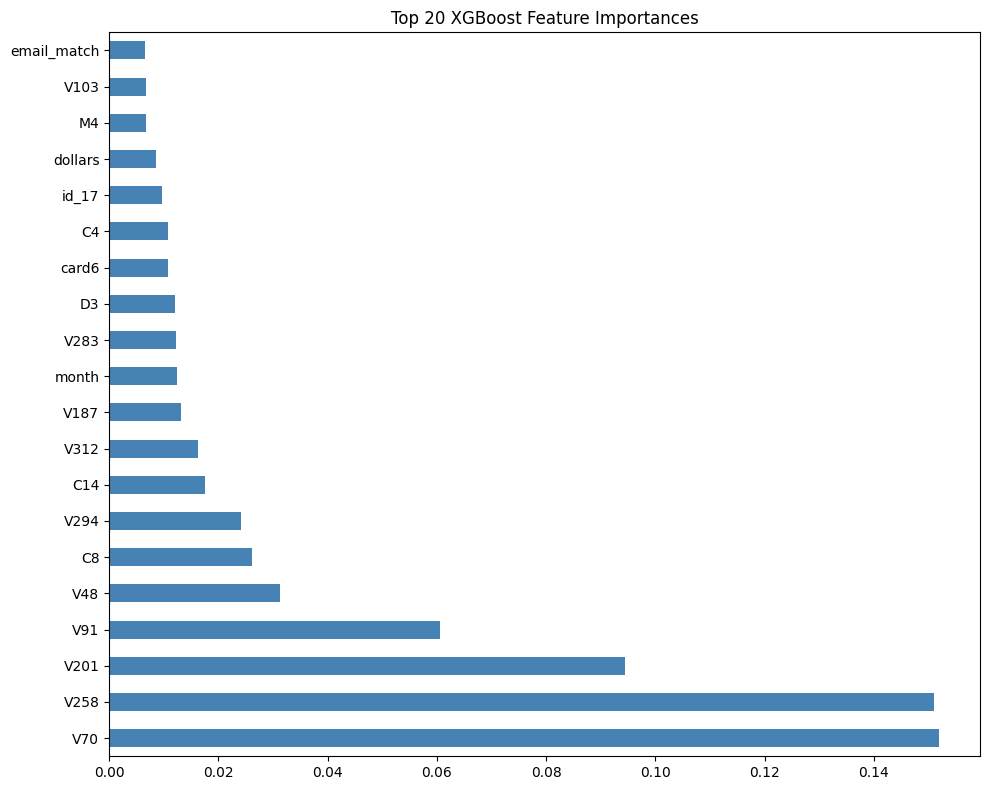

XGBoost importance kept: 241 features
Final shape: (472432, 241)
🏃 View run XGBoost_Feature_Selection_importance at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1/runs/39d114be87074524b23c3a95680605d2
🧪 View experiment at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1


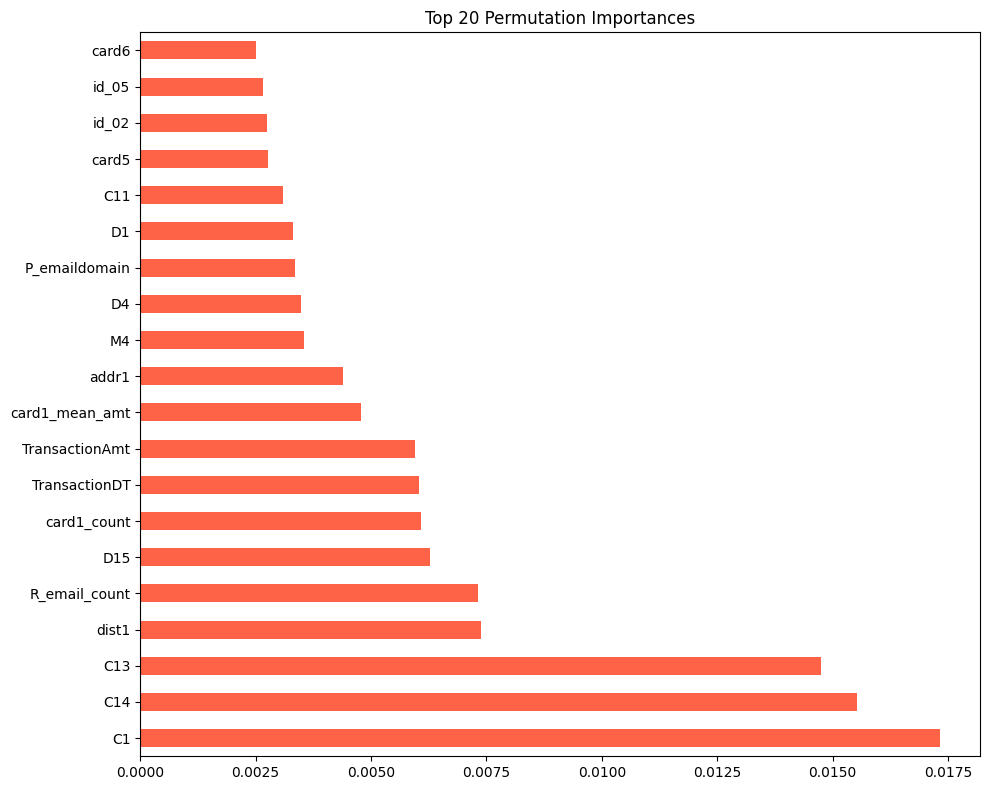

Permutation importance kept: 163 features
Final shape: (472432, 163)
🏃 View run XGBoost_Feature_Selection_permutation at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1/runs/bc4a4cfd355649a7930fd4fe2e4b7d0d
🧪 View experiment at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1

Final features for training: 163


In [9]:
from sklearn.feature_selection import SelectFromModel
from sklearn.inspection import permutation_importance

with mlflow.start_run(run_name="XGBoost_Feature_Selection_correlation"):
    # - method 1: correlation filter -
    correlations = pd.Series(
        np.abs(np.corrcoef(X_train_v1.T, y_train)[-1, :-1]),
        index=X_train_v1.columns
    )
    low_corr_cols = correlations[correlations < 0.005].index.tolist()
    X_train_fs = X_train_v1.drop(columns=low_corr_cols)
    X_test_fs  = X_test_v1.drop(columns=low_corr_cols)
    print(f"Correlation filter removed: {len(low_corr_cols)} features")
    print(f"Remaining: {X_train_fs.shape[1]}")
    mlflow.log_param("method", "correlation")
    mlflow.log_param("threshold", 0.005)
    mlflow.log_metric("features_removed", len(low_corr_cols))
    mlflow.log_metric("features_remaining", X_train_fs.shape[1])

with mlflow.start_run(run_name="XGBoost_Feature_Selection_importance"):
    # - method 2: XGBoost feature importance -
    selector_xgb = XGBClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42,
        scale_pos_weight=28,
        eval_metric='auc',
        verbosity=0
    )
    selector_xgb.fit(X_train_fs, y_train.values)
    
    importances = pd.Series(selector_xgb.feature_importances_, index=X_train_fs.columns)
    selected_cols = importances[importances > 0].index.tolist()
    
    X_train_fs = X_train_fs[selected_cols]
    X_test_fs  = X_test_fs[selected_cols]
    
    importances.nlargest(20).plot(kind='barh', figsize=(10, 8), color='steelblue')
    plt.title('Top 20 XGBoost Feature Importances')
    plt.tight_layout()
    plt.savefig('/kaggle/working/xgb_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"XGBoost importance kept: {len(selected_cols)} features")
    print(f"Final shape: {X_train_fs.shape}")
    mlflow.log_param("method", "xgb_importance_nonzero")
    mlflow.log_metric("features_remaining", X_train_fs.shape[1])
    mlflow.log_artifact('/kaggle/working/xgb_feature_importance.png')

with mlflow.start_run(run_name="XGBoost_Feature_Selection_permutation"):
    # - method 3: permutation importance -
    selector_xgb2 = XGBClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42,
        scale_pos_weight=28,
        eval_metric='auc',
        verbosity=0
    )
    selector_xgb2.fit(X_train_fs, y_train.values)
    
    X_sample = X_train_fs.sample(n=5000, random_state=42)
    y_sample = y_train.values[X_sample.index]
    
    perm_imp = permutation_importance(
        selector_xgb2, X_sample, y_sample,
        n_repeats=3, random_state=42, scoring='roc_auc'
    )
    perm_series = pd.Series(perm_imp.importances_mean, index=X_train_fs.columns)
    perm_selected = perm_series[perm_series > 0].index.tolist()
    
    X_train_fs = X_train_fs[perm_selected]
    X_test_fs  = X_test_fs[perm_selected]
    
    perm_series.nlargest(20).plot(kind='barh', figsize=(10, 8), color='tomato')
    plt.title('Top 20 Permutation Importances')
    plt.tight_layout()
    plt.savefig('/kaggle/working/xgb_permutation_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Permutation importance kept: {len(perm_selected)} features")
    print(f"Final shape: {X_train_fs.shape}")
    mlflow.log_param("method", "permutation_importance")
    mlflow.log_param("n_repeats", 3)
    mlflow.log_param("sample_size", 5000)
    mlflow.log_metric("features_remaining", X_train_fs.shape[1])
    mlflow.log_artifact('/kaggle/working/xgb_permutation_importance.png')

print(f"\nFinal features for training: {X_train_fs.shape[1]}")

## Training

In [18]:
# - baseline -
with mlflow.start_run(run_name="XGBoost_Baseline"):
    model = XGBClassifier(
        random_state=42,
        scale_pos_weight=28,
        eval_metric='auc',
        verbosity=0
    )
    model.fit(X_train_fs, y_train.values)
    y_pred       = model.predict(X_test_fs)
    y_pred_proba = model.predict_proba(X_test_fs)[:,1]
    train_auc    = roc_auc_score(y_train.values, model.predict_proba(X_train_fs)[:,1])
    test_auc     = roc_auc_score(y_test.values, y_pred_proba)
    f1           = f1_score(y_test.values, y_pred)
    print(f"Baseline | Train: {train_auc:.4f} | Test: {test_auc:.4f} | F1: {f1:.4f}")
    mlflow.log_params({"model": "baseline_default_params", "scale_pos_weight": 28})
    mlflow.log_metrics({"train_auc": train_auc, "test_auc": test_auc, "test_f1": f1})

# - underfit -
with mlflow.start_run(run_name="XGBoost_Underfit"):
    model = XGBClassifier(
        max_depth=2,
        n_estimators=50,
        learning_rate=0.01,
        random_state=42,
        scale_pos_weight=28,
        eval_metric='auc',
        verbosity=0
    )
    model.fit(X_train_fs, y_train.values)
    y_pred       = model.predict(X_test_fs)
    y_pred_proba = model.predict_proba(X_test_fs)[:,1]
    train_auc    = roc_auc_score(y_train.values, model.predict_proba(X_train_fs)[:,1])
    test_auc     = roc_auc_score(y_test.values, y_pred_proba)
    f1           = f1_score(y_test.values, y_pred)
    print(f"Underfit | Train: {train_auc:.4f} | Test: {test_auc:.4f} | F1: {f1:.4f}")
    mlflow.log_params({"max_depth": 2, "n_estimators": 50, "learning_rate": 0.01, "scale_pos_weight": 28})
    mlflow.log_metrics({"train_auc": train_auc, "test_auc": test_auc, "test_f1": f1})

# - overfit -
with mlflow.start_run(run_name="XGBoost_Overfit"):
    model = XGBClassifier(
        max_depth=15,
        n_estimators=1000,
        learning_rate=0.3,
        reg_alpha=0,
        reg_lambda=0,
        random_state=42,
        scale_pos_weight=28,
        eval_metric='auc',
        verbosity=0
    )
    model.fit(X_train_fs, y_train.values)
    y_pred       = model.predict(X_test_fs)
    y_pred_proba = model.predict_proba(X_test_fs)[:,1]
    train_auc    = roc_auc_score(y_train.values, model.predict_proba(X_train_fs)[:,1])
    test_auc     = roc_auc_score(y_test.values, y_pred_proba)
    f1           = f1_score(y_test.values, y_pred)
    print(f"Overfit  | Train: {train_auc:.4f} | Test: {test_auc:.4f} | F1: {f1:.4f}")
    mlflow.log_params({"max_depth": 15, "n_estimators": 1000, "learning_rate": 0.3,
                       "reg_alpha": 0, "reg_lambda": 0, "scale_pos_weight": 28})
    mlflow.log_metrics({"train_auc": train_auc, "test_auc": test_auc, "test_f1": f1})

Baseline | Train: 0.9748 | Test: 0.9255 | F1: 0.4333
🏃 View run XGBoost_Baseline at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1/runs/64492a739c8041eebf954105e94b79a7
🧪 View experiment at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1
Underfit | Train: 0.8246 | Test: 0.8258 | F1: 0.2146
🏃 View run XGBoost_Underfit at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1/runs/20d6433977d14759bf4c2b9413446c0e
🧪 View experiment at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1
Overfit  | Train: 1.0000 | Test: 0.9590 | F1: 0.7234
🏃 View run XGBoost_Overfit at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1/runs/765049d35fb04cb388e39f75d70709ce
🧪 View experiment at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1


In [19]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators':     trial.suggest_int('n_estimators', 100, 800),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0, 5),
        'scale_pos_weight': 28,
        'random_state':     42,
        'eval_metric':      'auc',
        'verbosity':        0
    }
    
    model = XGBClassifier(**params)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_fs, y_train.values, cv=cv, scoring='roc_auc')
    return scores.mean()

with mlflow.start_run(run_name="XGBoost_Optuna"):
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=50, show_progress_bar=True)
    
    best_params = study.best_params
    best_params['scale_pos_weight'] = 28
    best_params['random_state']     = 42
    best_params['eval_metric']      = 'auc'
    best_params['verbosity']        = 0
    
    print(f"\nBest CV AUC: {study.best_value:.4f}")
    print(f"Best params: {best_params}")
    
    mlflow.log_params(best_params)
    mlflow.log_metric("best_cv_auc", study.best_value)

  0%|          | 0/50 [00:00<?, ?it/s]


Best CV AUC: 0.9646
Best params: {'max_depth': 10, 'learning_rate': 0.062444282196610794, 'n_estimators': 800, 'subsample': 0.88575351403348, 'colsample_bytree': 0.7325400774730623, 'min_child_weight': 6, 'reg_alpha': 3.5727631235277175, 'reg_lambda': 0.004121703977623681, 'scale_pos_weight': 28, 'random_state': 42, 'eval_metric': 'auc', 'verbosity': 0}
🏃 View run XGBoost_Optuna at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1/runs/307156715199459285e4d378418eae36
🧪 View experiment at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1


In [20]:
with mlflow.start_run(run_name="XGBoost_v2_baseline"):
    
    # - encode and impute v2 -
    cat_cols = X_train_v2.select_dtypes(include='object').columns.tolist()
    for col in cat_cols:
        le = LabelEncoder()
        combined = pd.concat([X_train_v2[col], X_test_v2[col]], axis=0).astype(str)
        le.fit(combined)
        X_train_v2[col] = le.transform(X_train_v2[col].astype(str))
        X_test_v2[col]  = le.transform(X_test_v2[col].astype(str))
    
    imputer_v2 = SimpleImputer(strategy='median')
    X_train_v2 = pd.DataFrame(imputer_v2.fit_transform(X_train_v2), columns=X_train_v2.columns)
    X_test_v2  = pd.DataFrame(imputer_v2.transform(X_test_v2),      columns=X_test_v2.columns)
    
    # - train baseline xgboost on v2 -
    model_v2 = XGBClassifier(
        random_state=42,
        scale_pos_weight=28,
        eval_metric='auc',
        verbosity=0
    )
    model_v2.fit(X_train_v2, y_train.values)
    
    y_pred_v2       = model_v2.predict(X_test_v2)
    y_pred_proba_v2 = model_v2.predict_proba(X_test_v2)[:,1]
    train_auc_v2    = roc_auc_score(y_train.values, model_v2.predict_proba(X_train_v2)[:,1])
    test_auc_v2     = roc_auc_score(y_test.values, y_pred_proba_v2)
    f1_v2           = f1_score(y_test.values, y_pred_v2)
    
    print(f"v2 Baseline | Train: {train_auc_v2:.4f} | Test: {test_auc_v2:.4f} | F1: {f1_v2:.4f}")
    print(f"v1 Baseline | Train: 0.9748       | Test: 0.9255       | F1: 0.4333")
    
    mlflow.log_params({"threshold": 0.7, "model": "baseline", "scale_pos_weight": 28})
    mlflow.log_metrics({"train_auc": train_auc_v2, "test_auc": test_auc_v2, "test_f1": f1_v2})

v2 Baseline | Train: 0.9759 | Test: 0.9319 | F1: 0.4419
v1 Baseline | Train: 0.9748       | Test: 0.9255       | F1: 0.4333
🏃 View run XGBoost_v2_baseline at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1/runs/613c5ac1e8e04239a1441c39ae6aba74
🧪 View experiment at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1


In [21]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators':     trial.suggest_int('n_estimators', 100, 800),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0, 5),
        'scale_pos_weight': 28,
        'random_state':     42,
        'eval_metric':      'auc',
        'verbosity':        0
    }
    
    model = XGBClassifier(**params)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_v2, y_train.values, cv=cv, scoring='roc_auc')
    return scores.mean()

with mlflow.start_run(run_name="XGBoost_v2_Optuna"):
    study_v2 = optuna.create_study(direction='maximize')
    study_v2.optimize(objective, n_trials=30, show_progress_bar=True)
    
    best_params_v2 = study_v2.best_params
    best_params_v2['scale_pos_weight'] = 28
    best_params_v2['random_state']     = 42
    best_params_v2['eval_metric']      = 'auc'
    best_params_v2['verbosity']        = 0
    
    print(f"\nBest CV AUC: {study_v2.best_value:.4f}")
    print(f"Best params: {best_params_v2}")
    
    mlflow.log_params(best_params_v2)
    mlflow.log_metric("best_cv_auc", study_v2.best_value)

  0%|          | 0/30 [00:00<?, ?it/s]


Best CV AUC: 0.9621
Best params: {'max_depth': 10, 'learning_rate': 0.11448456859122526, 'n_estimators': 557, 'subsample': 0.9332005852891813, 'colsample_bytree': 0.8207735748578605, 'min_child_weight': 3, 'reg_alpha': 4.000990092499901, 'reg_lambda': 1.002824485543825, 'scale_pos_weight': 28, 'random_state': 42, 'eval_metric': 'auc', 'verbosity': 0}
🏃 View run XGBoost_v2_Optuna at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1/runs/258494bbbdad421fae46a4babddf9b47
🧪 View experiment at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1


In [22]:
# - train both best models and compare -
print("=== v1 Best Model ===")
best_model_v1 = XGBClassifier(**{
    'max_depth': 10, 'learning_rate': 0.062444282196610794,
    'n_estimators': 800, 'subsample': 0.88575351403348,
    'colsample_bytree': 0.7325400774730623, 'min_child_weight': 6,
    'reg_alpha': 3.5727631235277175, 'reg_lambda': 0.004121703977623681,
    'scale_pos_weight': 28, 'random_state': 42, 'eval_metric': 'auc', 'verbosity': 0
})
best_model_v1.fit(X_train_fs, y_train.values)
test_auc_v1 = roc_auc_score(y_test.values, best_model_v1.predict_proba(X_test_fs)[:,1])
f1_v1 = f1_score(y_test.values, best_model_v1.predict(X_test_fs))
print(f"Test AUC: {test_auc_v1:.4f} | F1: {f1_v1:.4f}")

print("\n=== v2 Best Model ===")
best_model_v2 = XGBClassifier(**{
    'max_depth': 10, 'learning_rate': 0.11448456859122526,
    'n_estimators': 557, 'subsample': 0.9332005852891813,
    'colsample_bytree': 0.8207735748578605, 'min_child_weight': 3,
    'reg_alpha': 4.000990092499901, 'reg_lambda': 1.002824485543825,
    'scale_pos_weight': 28, 'random_state': 42, 'eval_metric': 'auc', 'verbosity': 0
})
best_model_v2.fit(X_train_v2, y_train.values)
test_auc_v2 = roc_auc_score(y_test.values, best_model_v2.predict_proba(X_test_v2)[:,1])
f1_v2 = f1_score(y_test.values, best_model_v2.predict(X_test_v2))
print(f"Test AUC: {test_auc_v2:.4f} | F1: {f1_v2:.4f}")

=== v1 Best Model ===
Test AUC: 0.9626 | F1: 0.7359

=== v2 Best Model ===
Test AUC: 0.9621 | F1: 0.7357


## Construct and Log Best Pipeline

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

class DropHighMissing(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.8):
        self.threshold = threshold
    def fit(self, X, y=None):
        missing = X.isnull().mean()
        self.drop_cols_ = missing[missing > self.threshold].index.tolist()
        return self
    def transform(self, X):
        return X.drop(columns=[c for c in self.drop_cols_ if c in X.columns])

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.card1_stats_  = X.groupby('card1')['TransactionAmt'].agg(['mean','std'])
        uid                = X['card1'].astype(str) + '_' + X['card2'].astype(str)
        self.uid_stats_    = X.assign(uid=uid).groupby('uid')['TransactionAmt'].agg(['mean','std'])
        self.card1_counts_ = X['card1'].value_counts()
        return self
    def transform(self, X):
        X = X.copy()
        X['hour']  = (X['TransactionDT'] // 3600) % 24
        X['day']   = (X['TransactionDT'] // (3600 * 24)) % 7
        X['month'] = (X['TransactionDT'] // (3600 * 24 * 30)) % 12
        X['log_TransactionAmt'] = np.log1p(X['TransactionAmt'])
        X['cents']   = X['TransactionAmt'] - np.floor(X['TransactionAmt'])
        X['dollars'] = np.floor(X['TransactionAmt'])
        X['uid']  = X['card1'].astype(str) + '_' + X['card2'].astype(str)
        X['uid2'] = X['uid'] + '_' + X['card3'].astype(str)
        if 'P_emaildomain' in X.columns and 'R_emaildomain' in X.columns:
            X['email_match'] = (X['P_emaildomain'] == X['R_emaildomain']).astype(int)
        if 'P_emaildomain' in X.columns:
            X['P_email_count'] = X['P_emaildomain'].map(X['P_emaildomain'].value_counts())
        if 'R_emaildomain' in X.columns:
            X['R_email_count'] = X['R_emaildomain'].map(X['R_emaildomain'].value_counts())
        X['card1_count']       = X['card1'].map(self.card1_counts_)
        X['uid_count']         = X['uid'].map(X['uid'].value_counts())
        X['card1_mean_amt']    = X['card1'].map(self.card1_stats_['mean'])
        X['card1_std_amt']     = X['card1'].map(self.card1_stats_['std'])
        X['uid_mean_amt']      = X['uid'].map(self.uid_stats_['mean'])
        X['uid_std_amt']       = X['uid'].map(self.uid_stats_['std'])
        X['amt_deviation']     = X['TransactionAmt'] - X['card1_mean_amt']
        X['amt_deviation_uid'] = X['TransactionAmt'] - X['uid_mean_amt']
        if 'id_30' in X.columns:
            X['OS'] = X['id_30'].str.extract(r'^([a-zA-Z\s]+)')
        if 'id_31' in X.columns:
            X['browser'] = X['id_31'].str.extract(r'^([a-zA-Z\s]+)')
        return X

class LabelEncoderAll(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.encoders_ = {}
        for col in X.select_dtypes(include='object').columns:
            le = LabelEncoder()
            le.fit(X[col].astype(str))
            self.encoders_[col] = le
        return self
    def transform(self, X):
        X = X.copy()
        for col, le in self.encoders_.items():
            if col in X.columns:
                known = set(le.classes_)
                X[col] = X[col].astype(str).apply(lambda x: x if x in known else le.classes_[0])
                X[col] = le.transform(X[col])
        return X

class FeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        if hasattr(X, 'columns'):
            return X[[c for c in self.cols if c in X.columns]]
        else:
            return pd.DataFrame(X)[[c for c in self.cols if c in pd.DataFrame(X).columns]]

with mlflow.start_run(run_name="XGBoost_Best_Pipeline"):
    
    imputer = SimpleImputer(strategy='median')
    imputer.set_output(transform='pandas')
    
    pipeline = Pipeline([
        ('drop_missing',     DropHighMissing(threshold=0.8)),
        ('feature_eng',      FeatureEngineer()),
        ('label_enc',        LabelEncoderAll()),
        ('imputer',          imputer),
        ('feature_selector', FeatureSelector(cols=X_train_fs.columns.tolist())),
        ('model',            XGBClassifier(**{
            'max_depth': 10,
            'learning_rate': 0.062444282196610794,
            'n_estimators': 800,
            'subsample': 0.88575351403348,
            'colsample_bytree': 0.7325400774730623,
            'min_child_weight': 6,
            'reg_alpha': 3.5727631235277175,
            'reg_lambda': 0.004121703977623681,
            'scale_pos_weight': 28,
            'random_state': 42,
            'eval_metric': 'auc',
            'verbosity': 0
        }))
    ])
    
    # - use only train split rows, not full train -
    full_X = train.drop(columns=['isFraud', 'TransactionID'])
    X_train_raw = full_X.iloc[y_train.index]
    X_test_raw  = full_X.iloc[y_test.index]
    
    pipeline.fit(X_train_raw, y_train.values)
    
    y_pred       = pipeline.predict(X_test_raw)
    y_pred_proba = pipeline.predict_proba(X_test_raw)[:,1]
    test_auc     = roc_auc_score(y_test.values, y_pred_proba)
    f1           = f1_score(y_test.values, y_pred)
    precision    = precision_score(y_test.values, y_pred)
    recall       = recall_score(y_test.values, y_pred)
    
    print(f"Pipeline Test AUC: {test_auc:.4f}")
    print(f"F1: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")
    print(classification_report(y_test.values, y_pred))
    
    mlflow.log_params({
        'max_depth': 10,
        'learning_rate': 0.062444282196610794,
        'n_estimators': 800,
        'scale_pos_weight': 28,
        'missing_threshold': 0.8
    })
    mlflow.log_metrics({
        "test_auc": test_auc,
        "test_f1": f1,
        "test_precision": precision,
        "test_recall": recall
    })
    mlflow.sklearn.log_model(
        pipeline,
        "xgboost_pipeline",
        registered_model_name="XGBoost_Fraud_Pipeline"
    )
    print("Pipeline saved to registry as XGBoost_Fraud_Pipeline")

Pipeline Test AUC: 0.9724
F1: 0.8035 | Precision: 0.8680 | Recall: 0.7479
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    113975
           1       0.87      0.75      0.80      4133

    accuracy                           0.99    118108
   macro avg       0.93      0.87      0.90    118108
weighted avg       0.99      0.99      0.99    118108



2026/05/03 19:34:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 19:34:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'XGBoost_Fraud_Pipeline'.
2026/05/03 19:34:50 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: XGBoost_Fraud_Pipeline, version 1
Created version '1' of model 'XGBoost_Fraud_Pipeline'.


Pipeline saved to registry as XGBoost_Fraud_Pipeline
🏃 View run XGBoost_Best_Pipeline at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1/runs/f330ad790dc442dabb46a996206f2c08
🧪 View experiment at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/1
